No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


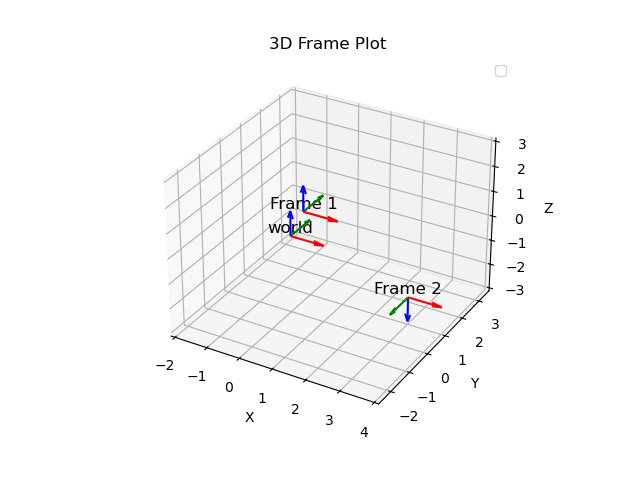

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from euler_quaternions import *
%matplotlib widget




def plot_frame(ax, x, y, z, q, length=1.0, frameName=""):
    """
    Plot a 3D frame with axes colored by red, green, and blue based on coordinates and quaternion.
    """
    R = quaternion_to_rotation_matrix(q)
    origin = np.array([[x, y, z]]).T

    axes = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]) * length
    transformed_axes = R @ axes + origin

    ax.quiver(origin[0, 0], origin[1, 0], origin[2, 0],
              transformed_axes[0, 0]-x, transformed_axes[1,
                                                         0]-y, transformed_axes[2, 0]-z,
              color='r', label='')
    ax.quiver(origin[0, 0], origin[1, 0], origin[2, 0],
              transformed_axes[0, 1]-x, transformed_axes[1,
                                                         1]-y, transformed_axes[2, 1]-z,
              color='g', label='')
    ax.quiver(origin[0, 0], origin[1, 0], origin[2, 0],
              transformed_axes[0, 2]-x, transformed_axes[1,
                                                         2]-y, transformed_axes[2, 2]-z,
              color='b', label='')

    # Set aspect ratio
    max_range = np.array([transformed_axes[:, 0].max()-transformed_axes[:, 0].min(),
                          transformed_axes[:, 1].max(
    )-transformed_axes[:, 1].min(),
        transformed_axes[:, 2].max()-transformed_axes[:, 2].min()]).max() / 2.0

    mid_x = (transformed_axes[:, 0].max() + transformed_axes[:, 0].min()) * 0.5
    mid_y = (transformed_axes[:, 1].max() + transformed_axes[:, 1].min()) * 0.5
    mid_z = (transformed_axes[:, 2].max() + transformed_axes[:, 2].min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.text(x, y, z, frameName, fontsize=12,
            color='black', ha='center', va='bottom')


if __name__ == "__main__":

    # Example usage:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # world
    length = 1.0
    x, y, z = 0, 0, 0
    q = [1, 0, 0, 0]

    plot_frame(ax, x, y, z, q, length, "world")

    # First frame
    x1, y1, z1 = 1, -1, 2
    q1 = [1, 0, 0, 0]  # Identity quaternion, no rotation

    plot_frame(ax, x1, y1, z1, q1, length, "Frame 1")

    # Optionally, add a second frame or other plot elements
    x2, y2, z2 = 3, 1, -2
    q2 = [0, 1, 0, 0]

    plot_frame(ax, x2, y2, z2, q2, length, "Frame 2")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Frame Plot')
    ax.legend()

    plt.show()
